# CSCI 6353 · Topic 6 — Monte Carlo Prediction

Estimate the state-value table of the 4×4 GridWorld under the random policy by averaging episode returns.

- Cell 1: GridWorld + random agent + MC learning loop (50,000 episodes) — prints the learned value table.
- Cell 2: same, plus a convergence plot for a few tracked states.

*Dr. Dongchul Kim · Summer II 2026*


In [1]:
import random
import numpy as np

class GridWorld():
    def __init__(self):
        self.x=0
        self.y=0

    def step(self, a):
        if a==0:
            self.move_left()
        elif a==1:
            self.move_up()
        elif a==2:
            self.move_right()
        elif a==3:
            self.move_down()

        reward = -1
        done = self.is_done()
        return (self.x, self.y), reward, done

    def move_right(self):
        self.y += 1
        if self.y > 3:
            self.y = 3

    def move_left(self):
        self.y -= 1
        if self.y < 0:
            self.y = 0

    def move_up(self):
        self.x -= 1
        if self.x < 0:
            self.x = 0

    def move_down(self):
        self.x += 1
        if self.x > 3:
            self.x = 3

    def is_done(self):
        if self.x == 3 and self.y == 3:
            return True
        else :
            return False

    def get_state(self):
        return (self.x, self.y)

    def reset(self):
        self.x = 0
        self.y = 0
        return (self.x, self.y)

class Agent():
    def __init__(self):
        pass

    def select_action(self):
        coin = random.random()
        if coin < 0.25:
            action = 0
        elif coin < 0.5:
            action = 1
        elif coin < 0.75:
            action = 2
        else:
            action = 3
        return action


def main():
    env = GridWorld()
    agent = Agent()
    data = [[0,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]]
    gamma = 1.0
    reward = -1
    alpha = 0.001

    for k in range(50000):
        done = False
        history = []

        while not done:
            action = agent.select_action()
            (x,y), reward, done = env.step(action)
            history.append((x,y,reward))
        env.reset()

        cum_reward = 0
        for transition in history[::-1]:
            x, y, reward = transition
            data[x][y] = data[x][y] + alpha*(cum_reward-data[x][y])
            cum_reward = reward + gamma*cum_reward

    for row in data:
        print(row)

if __name__ == '__main__':
    main()

[-58.53292975125042, -56.465695342591744, -54.189440217434125, -52.148828982028]
[-55.46498953801588, -53.12116368916038, -49.48278285234185, -43.383434699915895]
[-53.41920471730614, -47.99539557139796, -40.20173074676885, -28.34421863524469]
[-50.1489440337632, -43.341650139097325, -29.636726742992924, 0.0]


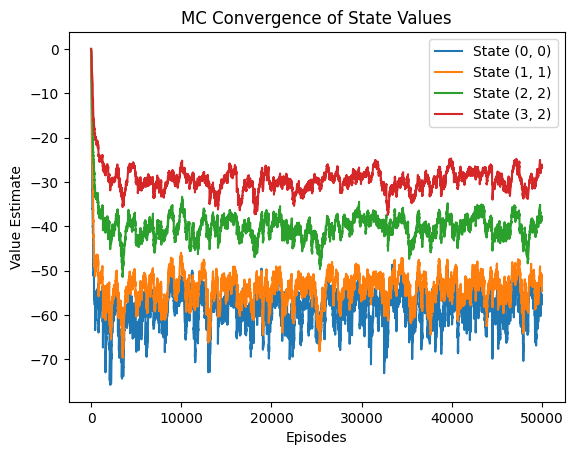

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

class GridWorld():
    def __init__(self):
        self.x=0
        self.y=0
    def step(self, a):
        if a==0: self.move_left()
        elif a==1: self.move_up()
        elif a==2: self.move_right()
        elif a==3: self.move_down()
        reward = -1
        done = self.is_done()
        return (self.x, self.y), reward, done
    def move_right(self): self.y = min(self.y+1, 3)
    def move_left(self):  self.y = max(self.y-1, 0)
    def move_up(self):    self.x = max(self.x-1, 0)
    def move_down(self):  self.x = min(self.x+1, 3)
    def is_done(self):    return self.x==3 and self.y==3
    def get_state(self):  return (self.x, self.y)
    def reset(self):
        self.x, self.y = 0, 0
        return (self.x, self.y)

class Agent():
    def select_action(self):
        return random.randint(0,3)

def main():
    env = GridWorld()
    agent = Agent()
    data = np.zeros((4,4))
    gamma = 1.0
    alpha = 0.001
    episodes = 50000

    # tracking states
    tracked_states = [(0,0), (1,1), (2,2), (3,2)]
    history_values = {s: [] for s in tracked_states}

    for k in range(episodes):
        done = False
        history = []
        while not done:
            action = agent.select_action()
            (x,y), reward, done = env.step(action)
            history.append((x,y,reward))
        env.reset()

        # backward return
        cum_reward = 0
        for transition in history[::-1]:
            x, y, reward = transition
            data[x][y] = data[x][y] + alpha*(cum_reward - data[x][y])
            cum_reward = reward + gamma*cum_reward

        # record
        for s in tracked_states:
            history_values[s].append(data[s[0], s[1]])

    # graph
    for s, values in history_values.items():
        plt.plot(values, label=f"State {s}")
    plt.xlabel("Episodes")
    plt.ylabel("Value Estimate")
    plt.title("MC Convergence of State Values")
    plt.legend()
    plt.show()

if __name__ == '__main__':
    main()
